In [1]:
import os
from pathlib import Path

DATA_DIR = Path(r"I:\Mon Drive\Quantum Internship - May-June 2026 - LIA Avignon\DATA\BQPGKA")

def parse_bqpgka(filepath):
    entries = []
    with open(filepath) as f:
        lines = [l.strip() for l in f if l.strip()]
    n, num_entries = map(int, lines[0].split())
    for line in lines[1:]:
        i, j, v = map(int, line.split())
        entries.append((i, j, v))
    return n, entries


files = sorted(f for f in DATA_DIR.iterdir() if f.suffix == '.txt')

print(f"{'File':<30} {'n':>5} {'diag>0?':>8} {'off<0?':>8} {'diag_eq?':>9} {'diag_val':>10} {'ok':>4}")
print("-" * 80)

all_ok = True

for fp in files:
    n, entries = parse_bqpgka(fp)

    diag    = {i: v for i, j, v in entries if i == j}
    offdiag = [(i, j, v) for i, j, v in entries if i != j]

    # Check 1: all diagonal terms > 0 (as stored; negate → < 0 in QUBO)
    diag_pos = all(v > 0 for v in diag.values())

    # Check 2: all off-diagonal terms < 0 (as stored; negate → > 0 in QUBO)
    offdiag_neg = all(v < 0 for _, _, v in offdiag)

    # Check 3: all diagonal terms equal
    diag_vals = list(diag.values())
    diag_equal = len(set(diag_vals)) == 1
    diag_summary = str(diag_vals[0]) if diag_equal else f"[{min(diag_vals)}..{max(diag_vals)}]"

    ok = diag_pos and offdiag_neg
    if not ok:
        all_ok = False

    bad_diag    = [(i, v) for i, v in diag.items() if v <= 0]
    bad_offdiag = [(i, j, v) for i, j, v in offdiag if v >= 0]

    flag = "OK" if ok else "FAIL"
    print(f"{fp.name:<30} {n:>5} {str(diag_pos):>8} {str(offdiag_neg):>8} {str(diag_equal):>9} {diag_summary:>10} {flag:>4}")

    if bad_diag:
        print(f"  !! Bad diagonal entries (should be >0): {bad_diag[:5]}")
    if bad_offdiag:
        print(f"  !! Bad off-diagonal entries (should be <0): {bad_offdiag[:5]}")

print()
if all_ok:
    print("All files consistent: diagonal > 0, off-diagonal < 0.")
    print("=> Negate all entries to get standard QUBO (diag < 0, off-diag > 0).")
else:
    print("Some files have inconsistencies — see FAIL rows above.")

File                               n  diag>0?   off<0?  diag_eq?   diag_val   ok
--------------------------------------------------------------------------------
bqpgka100_1.txt                  100    False    False     False [-99..100] FAIL
  !! Bad diagonal entries (should be >0): [(2, -89), (4, -56), (6, -90), (7, -89), (8, -39)]
  !! Bad off-diagonal entries (should be <0): [(1, 31, 78), (1, 62, 66), (1, 72, 24), (2, 69, 22), (3, 15, 15)]
bqpgka100_10.txt                 100    False    False     False  [-73..75] FAIL
  !! Bad diagonal entries (should be >0): [(3, -38), (5, -73), (7, -16), (8, -1), (9, -58)]
  !! Bad off-diagonal entries (should be <0): [(1, 2, 35), (1, 4, 6), (1, 5, 47), (1, 10, 41), (1, 13, 39)]
bqpgka100_11.txt                 100    False    False     False  [-75..75] FAIL
  !! Bad diagonal entries (should be >0): [(4, -18), (5, -27), (6, -6), (7, -65), (8, -57)]
  !! Bad off-diagonal entries (should be <0): [(1, 2, 14), (1, 3, 48), (1, 4, 39), (1, 5, 42), (1,

In [1]:
import numpy as np
from pathlib import Path

DATA_DIR = Path(r"I:\Mon Drive\Quantum Internship - May-June 2026 - LIA Avignon\DATA\BQPGKA")

def load_qubo(filepath):
    """
    Load a BQPGKA file and return Q in standard QUBO form (diag < 0, off-diag > 0).

    The file stores an upper-triangular matrix with negated values.
    The symmetric QUBO matrix is recovered as Q_sym = (Q_upper + Q_upper.T) / 2,
    which halves the off-diagonal entries — consistent with x^T Q x where Q is symmetric.
    """
    with open(filepath) as f:
        lines = [l.strip() for l in f if l.strip()]
    n, _ = map(int, lines[0].split())
    Q = np.zeros((n, n))
    for line in lines[1:]:
        i, j, v = map(int, line.split())
        i -= 1  # 1-indexed → 0-indexed
        j -= 1
        Q[i, j] = -v  # negate stored values
    Q = (Q + Q.T) / 2  # symmetrise upper triangle → full symmetric QUBO
    return Q


# --- Example: load one file and display Q ---
example_file = DATA_DIR / "bqpgka20_1.txt"
Q = load_qubo(example_file)

print(f"Q matrix from {example_file.name}  (shape {Q.shape})")
print(np.array2string(Q, precision=1, suppress_small=True))
print(f"\nDiagonal range   : [{Q.diagonal().min():.1f}, {Q.diagonal().max():.1f}]  (should be <0)")
mask = ~np.eye(len(Q), dtype=bool)
print(f"Off-diagonal range: [{Q[mask].min():.1f}, {Q[mask].max():.1f}]  (should be >0)")

Q matrix from bqpgka20_1.txt  (shape (20, 20))
[[-63.   31.5   5.5   8.5  33.   19.   47.5  29.   29.5  35.   33.5  19.5
   31.   34.5   3.   29.5  21.    7.5  33.5  17. ]
 [ 31.5 -41.   37.   39.   30.5  46.5  27.   42.    3.5  16.    1.   10.
   12.   12.5  47.5  36.   28.5  32.5   6.   41. ]
 [  5.5  37.  -44.   47.5  32.5  22.5   3.    1.5  22.5  31.5  35.   22.5
   36.5  16.5  28.   38.   25.    9.   16.5  36.5]
 [  8.5  39.   47.5  -2.    9.   10.5   4.5   4.5  16.   19.   37.   44.
   16.   41.   48.   23.5   0.5  34.   27.   13.5]
 [ 33.   30.5  32.5   9.  -25.   14.5  41.    0.   11.5  20.   28.   25.5
   16.   38.5  18.   29.5  36.5  25.5  49.5  38.5]
 [ 19.   46.5  22.5  10.5  14.5 -21.    6.    1.   13.   41.5  46.   12.
   41.5  19.5  15.5  37.5  18.   37.5  28.5   3.5]
 [ 47.5  27.    3.    4.5  41.    6.  -36.    2.   33.   34.5  48.5   5.
   48.5   4.5  41.   25.   42.    9.5  12.5  14.5]
 [ 29.   42.    1.5   4.5   0.    1.    2.  -25.   41.   24.5   3.   14.
   27.   

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform, euclidean

In [3]:
device = pulser.MockDevice
device.print_specs()

-------------------------
MockDevice Specifications
-------------------------
A virtual device for unconstrained prototyping.

Register parameters:
 - Dimensions: 3D
 - Minimum distance between neighbouring atoms: 0.0 μm

Layout parameters:
 - Requires layout: No
 - Minimal number of traps: 1
 - Minimum layout filling fraction: 0.0
 - Maximum layout filling fraction: 0.5

Device parameters:
 - Rydberg level: 70
 - Ising interaction coefficient: 5420158.53
 - XY interaction coefficient: 3700.0
 - Channels can be reused: Yes
 - Supported bases: digital, XY, ground-rydberg
 - Supported states: u, d, r, g, h
 - SLM Mask: Yes

Channels:
 - 'rydberg_global': Rydberg(addressing='Global',
        max_abs_detuning=None,
        max_amp=None,
        min_retarget_interval=None,
        fixed_retarget_t=None,
        max_targets=None,
        clock_period=1,
        min_duration=1,
        max_duration=None,
        min_avg_amp=0,
        mod_bandwidth=None,
        custom_phase_jump_time=None,
 

In [4]:
# Facteur de normalisation /4 : Compense le fait que la matrice Q théorique utilise 
# des couplages unitaires (1). Diviser par 4 tasse globalement l'échelle d'énergie,
# ce qui force l'optimiseur à rapprocher les atomes (~10.5 µm au lieu de ~13.2 µm).
# Grâce à la loi en 1/R^6, ce léger rapprochement multiplie par 4 la force réelle
# des interactions physiques, améliorant la robustesse au bruit de la machine.

def evaluate_mapping(
        new_coords: np.ndarray, Q: np.ndarray, device: pulser.devices.Device
):
    """ Cost function to minimize."""
    new_coords = np.reshape(new_coords, (len(Q),2))
    new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6) / 4 # <- Ce facteur
    return np.linalg.norm(new_Q - Q)

In [5]:
costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(~np.eye(Q.shape[0], dtype=bool) * Q, device),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None}
)
coords = np.reshape(res.x, (len(Q),2))

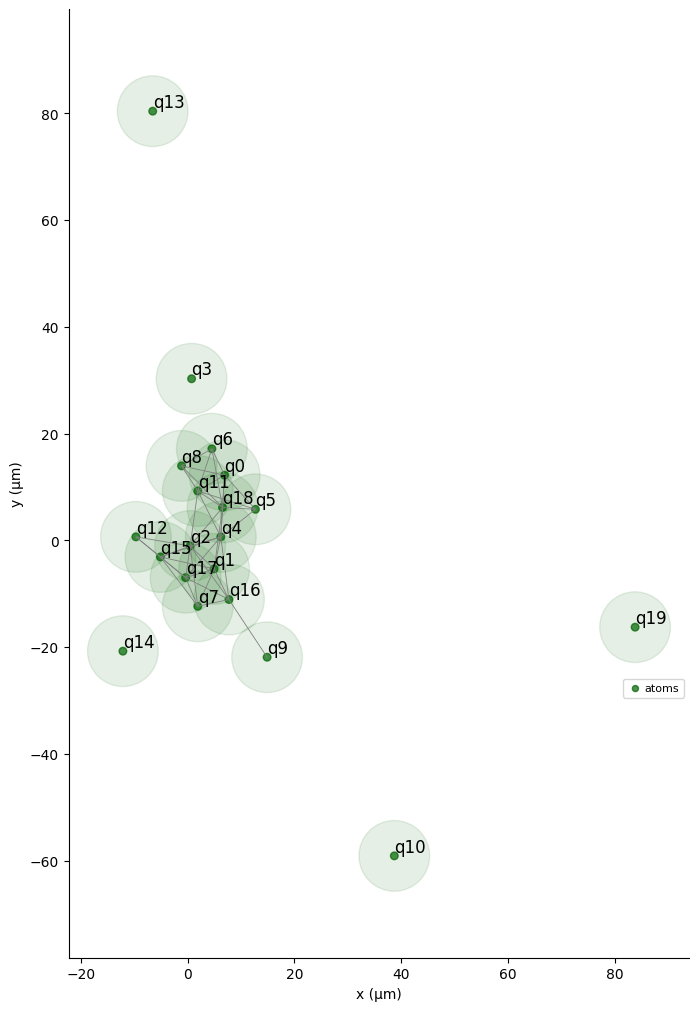

In [6]:
qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = pulser.Register(qubits)
reg.draw(
    blockade_radius=device.rydberg_blockade_radius(1.0),
    draw_graph=True,
    draw_half_radius=True
)

In [8]:
sequence = pulser.Sequence(reg, device)

In [9]:
sequence.declare_channel("rydberg_global", "rydberg_global")

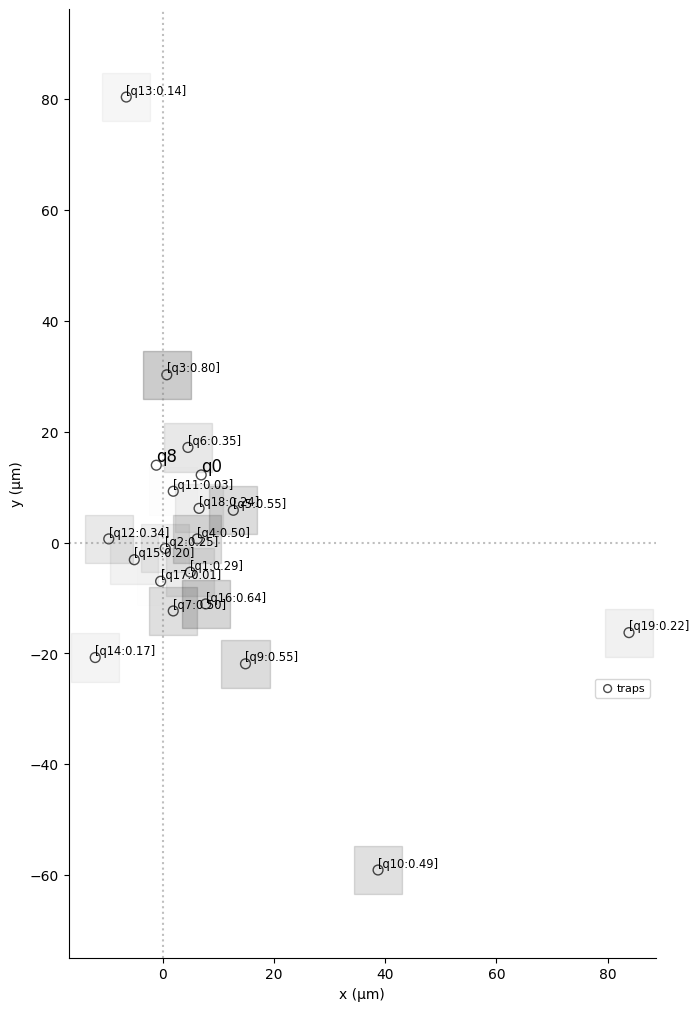

In [7]:
# Applciation du det map pour le QUBO
# Ici je veux favoriser l'activation des atomes dont le coeff diag est le plut petit
node_weights = np.diag(Q)
a = np.min(node_weights)
b = np.max(node_weights)
alpha = 0.8 # facteur de sécurité pour s'assurer que le Delta tot à la fin de la séquence soit > 0 pour tous les atomes

if b - a != 0:
    det_map_weights = alpha * (node_weights - a) / (b - a)
else:
    det_map_weights = np.zeros_like(node_weights)

det_map = reg.define_detuning_map(
    {f"q{i}": det_map_weights[i] for i in range(len(det_map_weights))}
)
det_map.draw(labels=reg.qubit_ids)

In [10]:
sequence.config_detuning_map(det_map, "dmm_0")

In [11]:
distances= []

for i in range(1, Q.shape[0]):
    for j in range(i - 1):
        distances.append(
            euclidean(reg.qubits[f"q{i}"], reg.qubits[f"q{j}"])
            )

Omega = device.interaction_coeff /  np.min(distances) ** 6

delta_0 = - Omega #Just need a <0 real
delta_f = - delta_0 #Just needs to be >0 real
T = 40000 # Time in ns : it should be long enough to ensure information propagation (<=> adiabatic)

print(f"Omega : {Omega}")
print(f"delta_0 : {delta_0}")
print(f"delta_f : {delta_f}")

Omega : 195.1460705289907
delta_0 : -195.1460705289907
delta_f : 195.1460705289907


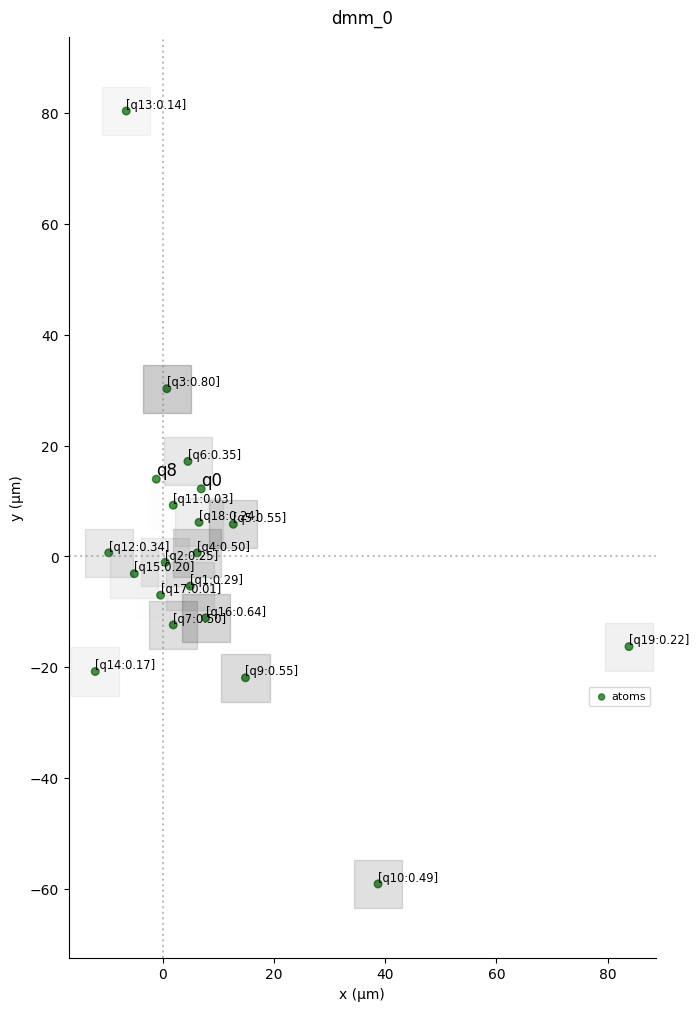

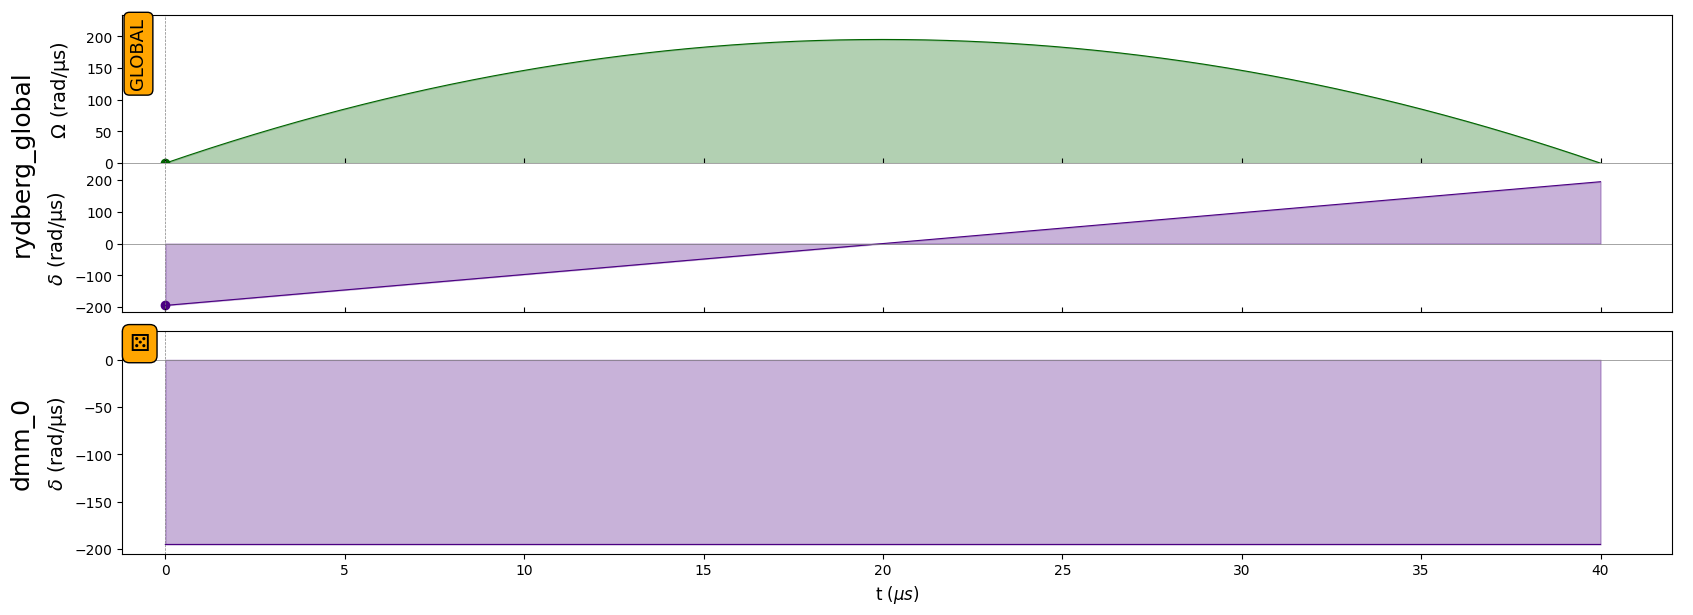

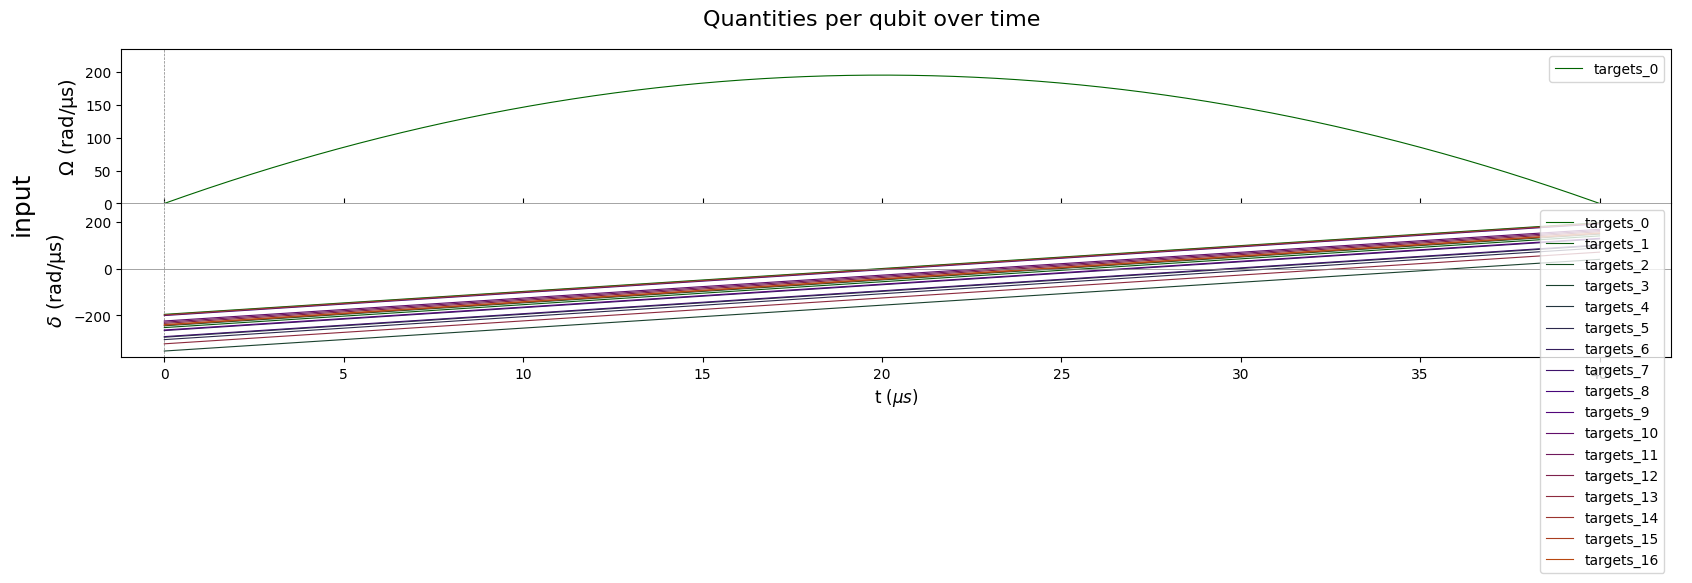

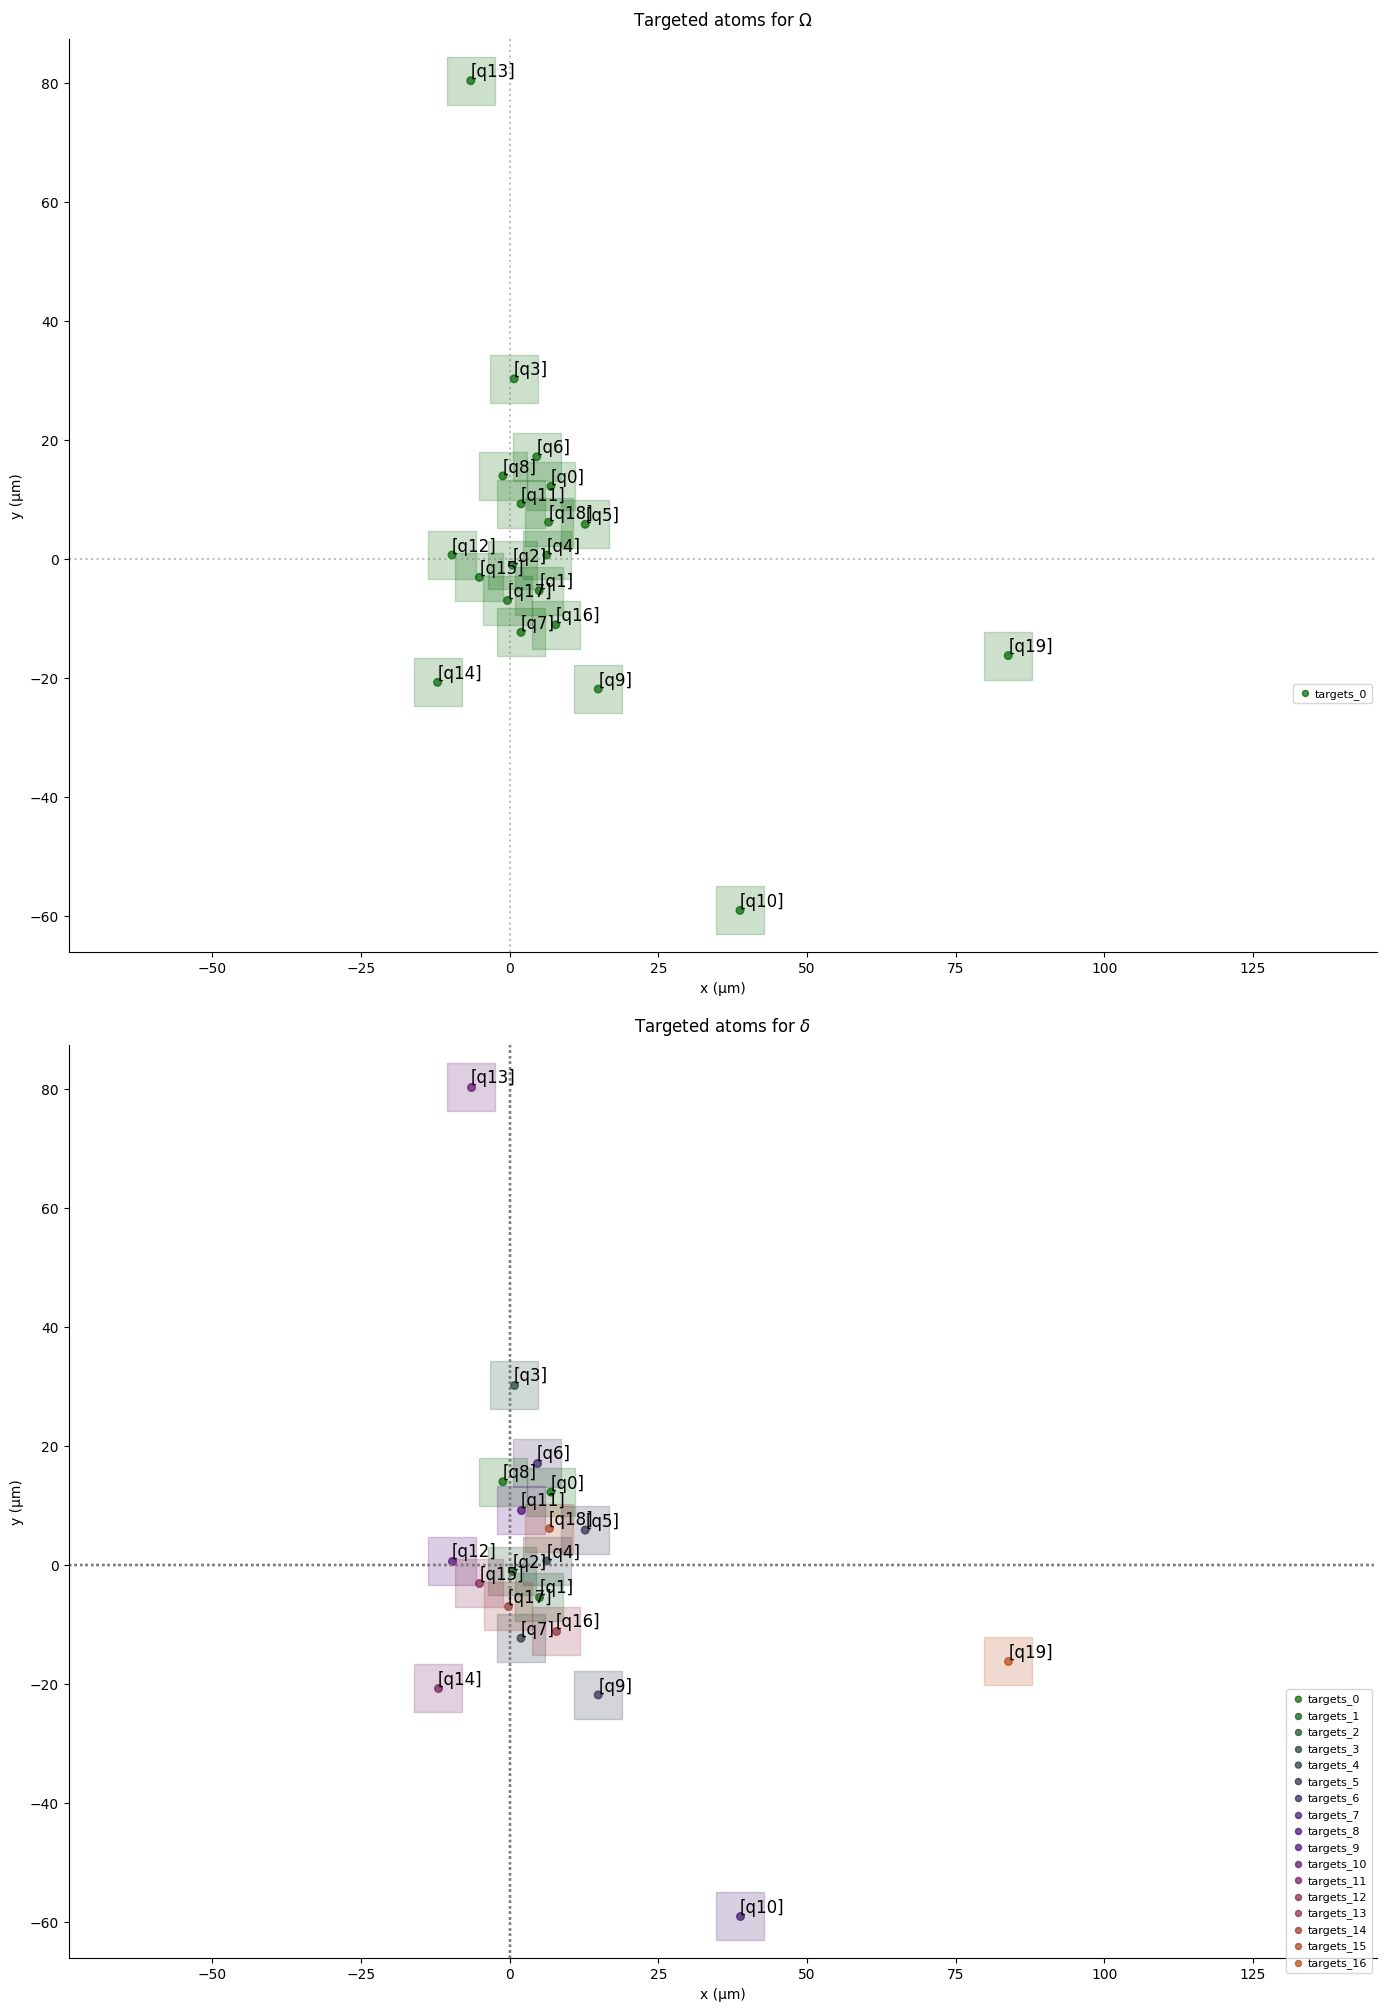

In [12]:
#Adiabatic pulse added to the Rydberg Global
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0
)
sequence.add(adiabatic_pulse, "rydberg_global")

# Constant pulse added to the DMM
sequence.add_dmm_detuning(pulser.ConstantWaveform(T, -delta_f), "dmm_0")
sequence.draw(
    draw_detuning_maps=True,
    draw_qubit_det=True,
    draw_qubit_amp=True,
)

In [ ]:
simul = pulser_simulation.QutipBackendV2(sequence)
results = simul.run()
count_dict = results.final_bitstrings

In [ ]:
def plot_distribution(C):
    C = dict(sorted(C.items(), key=lambda item: item[1], reverse=True))
    indexes = [] #best solution
    color_dict = {key: "r" if key in indexes else "g" for key in C}
    plt.figure(figsize=(12, 6))
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.bar(C.keys(), C.values(), width=0.5, color=color_dict.values())
    plt.xticks(rotation="vertical")
    plt.show()

In [ ]:
plot_distribution(count_dict)